# PaleoWave — 06 Model v2 with TPI Feature
**Project PaleoWave | Notebook 06**

Retrains the Random Forest with TPI added as a 5th feature, then
re-scores all 50 priority targets using the updated composite score.

## Feature set
| Feature | v1 | v2 |
|:--------|:--:|:--:|
| elevation_m | ✓ | ✓ |
| slope_deg | ✓ | ✓ |
| aspect_deg | ✓ | ✓ |
| tri | ✓ | ✓ |
| tpi_15m | — | ✓ NEW |

## What this notebook does
1. Load presence features + TPI from notebook 05 cache
2. Generate background points with TPI (or load cache)
3. Train RF v1 and v2 — compare feature importance
4. Fetch TPI for remaining targets (ranks 21–50)
5. Score all 50 targets with v2 model
6. Re-rank — show movers
7. Save updated CSV and GeoJSON

In [1]:
# ── Cell 1: Imports and config ─────────────────────────────────────────────
import requests, time, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from scipy.ndimage import uniform_filter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from pathlib import Path

DATA_DIR  = Path('../data')
MODEL_DIR = DATA_DIR / 'model'
PBDB_DIR  = DATA_DIR / 'pbdb'
LIDAR_DIR = DATA_DIR / 'lidar'
OUT_DIR   = Path('../outputs')

TNM_URL    = 'https://elevation.nationalmap.gov/arcgis/rest/services/3DEPElevation/ImageServer'
TPI_RADIUS = 100
MAX_PX     = 500
FETCH_RES  = 0.00016
TILE_BUF   = 0.05

FEATURE_COLS_V1 = ['elevation_m', 'slope_deg', 'aspect_deg', 'tri']
FEATURE_COLS_V2 = ['elevation_m', 'slope_deg', 'aspect_deg', 'tri', 'tpi_15m']
RF_PARAMS = dict(n_estimators=500, max_depth=6,
                 class_weight='balanced', random_state=42, n_jobs=-1)

print('Imports OK')
print(f'v1 features: {FEATURE_COLS_V1}')
print(f'v2 features: {FEATURE_COLS_V2}')

Imports OK
v1 features: ['elevation_m', 'slope_deg', 'aspect_deg', 'tri']
v2 features: ['elevation_m', 'slope_deg', 'aspect_deg', 'tri', 'tpi_15m']


In [2]:
# ── Cell 2: DTM / TPI utility functions ───────────────────────────────────

def fetch_dtm(lat, lon, buf=TILE_BUF, label='pt'):
    xmin, xmax = lon - buf, lon + buf
    ymin, ymax = lat - buf, lat + buf
    n = min(MAX_PX, int(buf * 2 / FETCH_RES))
    params = dict(
        bbox=f'{xmin},{ymin},{xmax},{ymax}', bboxSR='4326',
        size=f'{n},{n}', imageSR='4326', format='tiff',
        pixelType='F32', noDataInterpretation='esriNoDataMatchAny',
        interpolation='RSP_BilinearInterpolation', f='image'
    )
    for attempt in range(3):
        try:
            r = requests.get(f'{TNM_URL}/exportImage', params=params, timeout=60)
            r.raise_for_status()
            if len(r.content) < 1000: return None, None
            with rasterio.MemoryFile(r.content) as mf:
                with mf.open() as src:
                    dem = src.read(1).astype(np.float32)
                    tf  = src.transform
                    nd  = src.nodata
            if nd is not None: dem[dem == nd] = np.nan
            dem[dem < -500] = np.nan
            return dem, tf
        except requests.exceptions.ReadTimeout:
            if attempt < 2:
                print(f'  {label}: timeout, retry {attempt+2}/3...')
                time.sleep(2)
        except Exception:
            return None, None
    return None, None

def compute_tpi(dem):
    d = dem.copy()
    nm = np.isnan(d)
    if nm.any():
        tmp = uniform_filter(np.where(nm, 0., d), size=5)
        cnt = uniform_filter((~nm).astype(float), size=5)
        d[nm] = np.where(cnt[nm] > 0, tmp[nm]/cnt[nm], 0)
    return d - uniform_filter(d, size=TPI_RADIUS * 2 + 1)

def px_val(arr, tf, lat, lon):
    r = int((lat - tf.f) / tf.e)
    c = int((lon - tf.c) / tf.a)
    if 0 <= r < arr.shape[0] and 0 <= c < arr.shape[1]:
        return float(arr[r, c])
    return np.nan

def get_tpi(lat, lon, label='pt'):
    dem, tf = fetch_dtm(lat, lon, label=label)
    if dem is None: return np.nan
    return px_val(compute_tpi(dem), tf, lat, lon)

print('Functions OK')

Functions OK


In [3]:
# ── Cell 3: Load presence features + TPI ──────────────────────────────────

pres_tpi_path = PBDB_DIR / 'pbdb_presence_tpi.csv'
terrain_path  = DATA_DIR / 'features_pbdb_terrain.csv'

df_terrain = pd.read_csv(terrain_path)

if pres_tpi_path.exists():
    df_tpi = pd.read_csv(pres_tpi_path)[['occurrence_id', 'tpi_15m']]
    df_pres = df_terrain.merge(df_tpi, on='occurrence_id', how='left')
    print('TPI merged from notebook 05 cache')
else:
    print('Cache not found — fetching TPI now...')
    vals = []
    for i, (_, row) in enumerate(df_terrain.iterrows()):
        v = get_tpi(row['latitude'], row['longitude'], label=f'pres{i+1}')
        vals.append(v)
        print(f'  {i+1}/{len(df_terrain)}: {v:+.1f}m' if not np.isnan(v) else f'  {i+1}: NaN')
    df_pres = df_terrain.copy()
    df_pres['tpi_15m'] = vals

df_pres_v2 = (df_pres
    .drop_duplicates(subset=['latitude','longitude'])
    .dropna(subset=FEATURE_COLS_V2)
    .copy())
df_pres_v2['label'] = 1

print(f'Total presence rows:            {len(df_terrain)}')
print(f'Unique locations:               {df_pres.drop_duplicates(["latitude","longitude"]).shape[0]}')
print(f'Valid for v2 (have TPI):        {len(df_pres_v2)}')
print(f'TPI mean={df_pres_v2.tpi_15m.mean():+.1f}m  median={df_pres_v2.tpi_15m.median():+.1f}m')

TPI merged from notebook 05 cache
Total presence rows:            27
Unique locations:               16
Valid for v2 (have TPI):        16
TPI mean=-37.4m  median=-45.2m


In [4]:
# ── Cell 4: Background points with TPI ────────────────────────────────────

bg_cache_path = PBDB_DIR / 'paleowave_background_v2.csv'

if bg_cache_path.exists():
    df_bg = pd.read_csv(bg_cache_path)
    print(f'Background loaded from cache: {len(df_bg)} points')
else:
    N_BG   = len(df_pres_v2) * 10
    rng    = np.random.default_rng(42)
    lat_lo = df_terrain['latitude'].min()  - 0.5
    lat_hi = df_terrain['latitude'].max()  + 0.5
    lon_lo = df_terrain['longitude'].min() - 0.5
    lon_hi = df_terrain['longitude'].max() + 0.5
    bg_lats = rng.uniform(lat_lo, lat_hi, N_BG * 2)
    bg_lons = rng.uniform(lon_lo, lon_hi, N_BG * 2)
    print(f'Fetching {N_BG} background points...')

    rows = []
    for i, (blat, blon) in enumerate(zip(bg_lats, bg_lons)):
        if len(rows) >= N_BG: break
        dem, tf = fetch_dtm(blat, blon, buf=0.03, label=f'bg{i+1}')
        if dem is None: continue
        tpi = compute_tpi(dem)
        res_m = FETCH_RES * 111000
        dz_dx = np.gradient(dem, axis=1) / res_m
        dz_dy = np.gradient(dem, axis=0) / res_m
        slope_a  = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))
        aspect_a = np.degrees(np.arctan2(-dz_dy, dz_dx)) % 360
        tri_a    = np.abs(dem - uniform_filter(dem, size=3))
        vals = [px_val(a, tf, blat, blon) for a in [dem, slope_a, aspect_a, tri_a, tpi]]
        if any(np.isnan(vals)): continue
        rows.append(dict(latitude=blat, longitude=blon,
                         elevation_m=vals[0], slope_deg=vals[1],
                         aspect_deg=vals[2], tri=vals[3], tpi_15m=vals[4], label=0))
        if len(rows) % 20 == 0:
            print(f'  {len(rows)}/{N_BG}...')

    df_bg = pd.DataFrame(rows)
    df_bg.to_csv(bg_cache_path, index=False)
    print(f'Background saved: {len(df_bg)} points')

df_bg['label'] = 0
print(f'Background TPI mean={df_bg.tpi_15m.mean():+.1f}m  median={df_bg.tpi_15m.median():+.1f}m')

Fetching 160 background points...
  20/160...
  40/160...
  60/160...
  80/160...
  100/160...
  120/160...
  140/160...
  160/160...
Background saved: 160 points
Background TPI mean=+0.2m  median=-3.3m


Training v1: 16 pres + 160 bg
Training v2: 16 pres + 160 bg
Train AUC v1: 1.000
Train AUC v2: 1.000
(train AUC is optimistic — LOO validation in notebook 07)


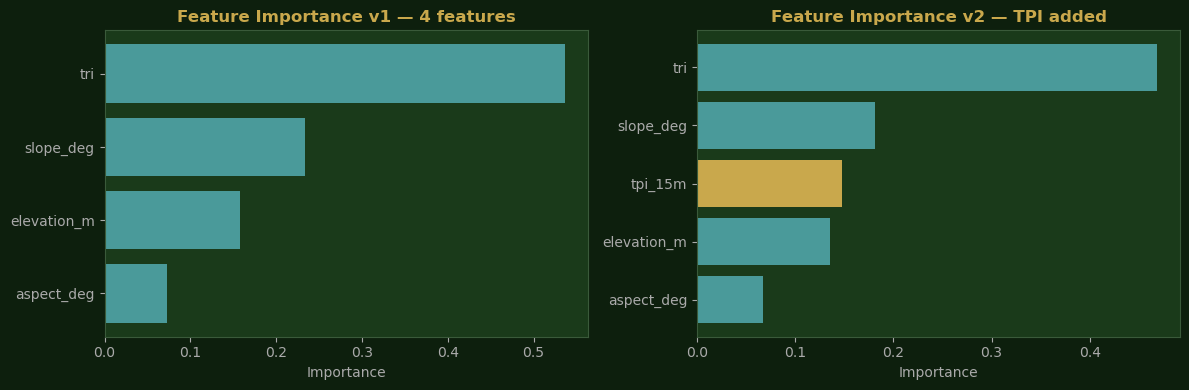

Saved: outputs/feature_importance_v2.png


In [5]:
# ── Cell 5: Train RF v1 and v2, compare feature importance ────────────────

train_v1 = pd.concat([df_pres_v2[FEATURE_COLS_V1+['label']],
                      df_bg[FEATURE_COLS_V1+['label']].dropna()], ignore_index=True)
train_v2 = pd.concat([df_pres_v2[FEATURE_COLS_V2+['label']],
                      df_bg[FEATURE_COLS_V2+['label']].dropna()], ignore_index=True)

X1, y1 = train_v1[FEATURE_COLS_V1].values, train_v1['label'].values
X2, y2 = train_v2[FEATURE_COLS_V2].values, train_v2['label'].values

print(f'Training v1: {y1.sum()} pres + {(y1==0).sum()} bg')
print(f'Training v2: {y2.sum()} pres + {(y2==0).sum()} bg')

rf1 = RandomForestClassifier(**RF_PARAMS).fit(X1, y1)
rf2 = RandomForestClassifier(**RF_PARAMS).fit(X2, y2)

auc1 = roc_auc_score(y1, rf1.predict_proba(X1)[:,1])
auc2 = roc_auc_score(y2, rf2.predict_proba(X2)[:,1])
print(f'Train AUC v1: {auc1:.3f}')
print(f'Train AUC v2: {auc2:.3f}')
print('(train AUC is optimistic — LOO validation in notebook 07)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0d1f0d')
for ax, rf, cols, title in [
        (axes[0], rf1, FEATURE_COLS_V1, 'v1 — 4 features'),
        (axes[1], rf2, FEATURE_COLS_V2, 'v2 — TPI added')]:
    imp = rf.feature_importances_
    idx = np.argsort(imp)
    clrs = ['#c9a84c' if cols[i]=='tpi_15m' else '#4a9a9a' for i in idx]
    ax.barh([cols[i] for i in idx], imp[idx], color=clrs)
    ax.set_title(f'Feature Importance {title}', color='#c9a84c', fontweight='bold')
    ax.set_xlabel('Importance', color='#aaaaaa')
    ax.set_facecolor('#1a3a1a'); ax.tick_params(colors='#aaaaaa')
    for sp in ax.spines.values(): sp.set_edgecolor('#3a5a3a')
fig.patch.set_facecolor('#0d1f0d')
plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance_v2.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1f0d')
plt.show()
print('Saved: outputs/feature_importance_v2.png')

In [9]:
# ── Cell 6 REPLACEMENT: Fetch terrain features for all 50 targets ──────────

target_features_path = MODEL_DIR / 'paleowave_target_features.csv'

if target_features_path.exists():
    df_feat = pd.read_csv(target_features_path)
    print(f'Target features loaded from cache: {len(df_feat)} rows')
else:
    gdf_t   = gpd.read_file(MODEL_DIR / 'priority_targets.geojson')
    df_all0 = pd.DataFrame(gdf_t.drop(columns='geometry'))
    # merge in tpi_15m from notebook 05 cache
    df_tpi_all = pd.read_csv(tpi_all_path) if tpi_all_path.exists() else pd.DataFrame()

    rows = []
    for i, (_, row) in enumerate(df_all0.iterrows()):
        rank = int(row['priority'])
        lat, lon = row['latitude'], row['longitude']
        print(f'[{i+1:2d}/50] P{rank:02d}  {lat:.4f}N {abs(lon):.4f}W', end=' ... ')

        dem, tf = fetch_dtm(lat, lon, buf=0.05, label=f'P{rank:02d}')
        if dem is None:
            print('FAILED')
            rows.append(dict(priority=rank, latitude=lat, longitude=lon,
                             elevation_m=np.nan, slope_deg=np.nan,
                             aspect_deg=np.nan, tri=np.nan, tpi_15m=np.nan))
            continue

        tpi_arr  = compute_tpi(dem)
        res_m    = FETCH_RES * 111000
        dz_dx    = np.gradient(dem, axis=1) / res_m
        dz_dy    = np.gradient(dem, axis=0) / res_m
        slope_a  = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))
        aspect_a = np.degrees(np.arctan2(-dz_dy, dz_dx)) % 360
        tri_a    = np.abs(dem - uniform_filter(dem, size=3))

        elev_v  = px_val(dem,      tf, lat, lon)
        slope_v = px_val(slope_a,  tf, lat, lon)
        asp_v   = px_val(aspect_a, tf, lat, lon)
        tri_v   = px_val(tri_a,    tf, lat, lon)
        tpi_v   = px_val(tpi_arr,  tf, lat, lon)

        print(f'elev={elev_v:.0f}m  slope={slope_v:.1f}°  TPI={tpi_v:+.1f}m')
        rows.append(dict(priority=rank, latitude=lat, longitude=lon,
                         elevation_m=elev_v, slope_deg=slope_v,
                         aspect_deg=asp_v, tri=tri_v, tpi_15m=tpi_v))

    df_feat = pd.DataFrame(rows)
    df_feat.to_csv(target_features_path, index=False)
    print(f'\nSaved: {target_features_path}')

# Merge terrain features + metadata back together
gdf_t  = gpd.read_file(MODEL_DIR / 'priority_targets.geojson')
df_all = pd.DataFrame(gdf_t.drop(columns='geometry'))
# drop any stale tpi_15m column from the geojson before merging
df_all = df_all.drop(columns=['tpi_15m'], errors='ignore')
df_all = df_all.merge(
    df_feat[['priority','elevation_m','slope_deg','aspect_deg','tri','tpi_15m']],
    on='priority', how='left'
)
print(f'Columns now: {df_all.columns.tolist()}')
print(f'TPI coverage: {df_all.tpi_15m.notna().sum()}/50')
print(f'Full feature coverage: {df_all[FEATURE_COLS_V2].notna().all(axis=1).sum()}/50')

[ 1/50] P01  40.4047N 118.2439W ... elev=1732m  slope=35.0°  TPI=+125.3m
[ 2/50] P02  40.2092N 117.5878W ... elev=1733m  slope=34.2°  TPI=-1.3m
[ 3/50] P03  40.5503N 118.2325W ... elev=1668m  slope=35.3°  TPI=+6.3m
[ 4/50] P04  40.4344N 117.6867W ... elev=1536m  slope=10.1°  TPI=+6.8m
[ 5/50] P05  40.8397N 117.7208W ... elev=1697m  slope=33.6°  TPI=+93.7m
[ 6/50] P06  40.8228N 117.6969W ... elev=1713m  slope=34.0°  TPI=-27.2m
[ 7/50] P07  40.4189N 117.7044W ... elev=1557m  slope=10.6°  TPI=-15.6m
[ 8/50] P08  40.7872N 117.4564W ... elev=1427m  slope=10.1°  TPI=-65.4m
[ 9/50] P09  40.9072N 118.4644W ... elev=1436m  slope=10.5°  TPI=+0.9m
[10/50] P10  40.1131N 117.2025W ... elev=1510m  slope=10.8°  TPI=-4.5m
[11/50] P11  40.1392N 117.4722W ... elev=1668m  slope=34.2°  TPI=+39.8m
[12/50] P12  40.1131N 117.2028W ... elev=1510m  slope=10.8°  TPI=-5.6m
[13/50] P13  40.2653N 117.4797W ... elev=1473m  slope=10.2°  TPI=-14.7m
[14/50] P14  40.4011N 117.2078W ... elev=1697m  slope=35.2°  TPI=+61.

In [13]:
# ── Cell 7: Score all 50 targets — TPI as post-hoc bonus (not model feature) ──

def tpi_bonus(tpi, dist_m):
    """
    TPI adjustment applied only within 15km of TRc formation.
    Rewards basin terrain, penalizes ridges.
    Range: -0.05 to +0.10 added to v1 composite_score.
    """
    if dist_m > 15000:
        return 0.0
    if   tpi < -10:  return  0.10
    elif tpi <  -3:  return  0.05
    elif tpi <   3:  return  0.00
    else:            return -0.05   # ridge — penalize

df_score = df_all.copy()
df_score['tpi_adj']      = df_score.apply(
    lambda r: tpi_bonus(r['tpi_15m'], r['dist_to_triassic_m']), axis=1)
df_score['composite_v2'] = df_score['composite_score'] + df_score['tpi_adj']
df_score['rank_v2']      = df_score['composite_v2'].rank(ascending=False).astype(int)
df_score['rank_v1']      = df_score['priority']
df_score['rank_delta']   = df_score['rank_v1'] - df_score['rank_v2']

df_out = df_score.sort_values('rank_v2').reset_index(drop=True)
df_out.to_csv(MODEL_DIR / 'paleowave_v2_top50.csv', index=False)
gpd.GeoDataFrame(
    df_out,
    geometry=gpd.points_from_xy(df_out['longitude'], df_out['latitude']),
    crs='EPSG:4326'
).to_file(MODEL_DIR / 'paleowave_v2_top50.geojson', driver='GeoJSON')

print('Top 20 (v2 rank):')
print(f'{"#":<4s} {"Coords":26s} {"v1sc":6s} {"TPIadj":7s} {"Comp":6s} {"TPI":8s} {"Move":6s} {"Dist TRc"}')
print('-' * 82)
for _, row in df_out.head(20).iterrows():
    d = int(row['rank_delta'])
    arrow  = f'↑{d}' if d > 0 else (f'↓{abs(d)}' if d < 0 else '─')
    coords = f"{row['latitude']:.4f}N {abs(row['longitude']):.4f}W"
    print(f"#{int(row['rank_v2']):<3d} {coords:26s} {row['composite_score']:.3f}  "
          f"{row['tpi_adj']:+.2f}   {row['composite_v2']:.3f}  "
          f"{row['tpi_15m']:+7.1f}m  {arrow:6s} {int(row['dist_to_triassic_m'])}m")

Top 20 (v2 rank):
#    Coords                     v1sc   TPIadj  Comp   TPI      Move   Dist TRc
----------------------------------------------------------------------------------
#1   40.8228N 117.6969W         0.890  +0.10   0.990    -27.2m  ↑5     1309m
#2   40.4189N 117.7044W         0.880  +0.10   0.980    -15.6m  ↑5     3338m
#3   40.7872N 117.4564W         0.853  +0.10   0.953    -65.4m  ↑5     13040m
#4   40.4047N 118.2439W         1.000  -0.05   0.950   +125.3m  ↓3     52m
#5   40.2653N 117.4797W         0.843  +0.10   0.943    -14.7m  ↑8     4157m
#6   40.1131N 117.2025W         0.849  +0.05   0.899     -4.5m  ↑4     4801m
#7   40.7997N 118.1403W         0.797  +0.10   0.897    -32.0m  ↑21    14464m
#8   40.0956N 117.2456W         0.796  +0.10   0.896    -23.0m  ↑24    7060m
#8   40.0956N 117.2456W         0.796  +0.10   0.896    -37.7m  ↑24    7060m
#10  40.2092N 117.5878W         0.895  +0.00   0.895     -1.3m  ↓8     992m
#11  40.3719N 117.5769W         0.794  +0.10   0.89

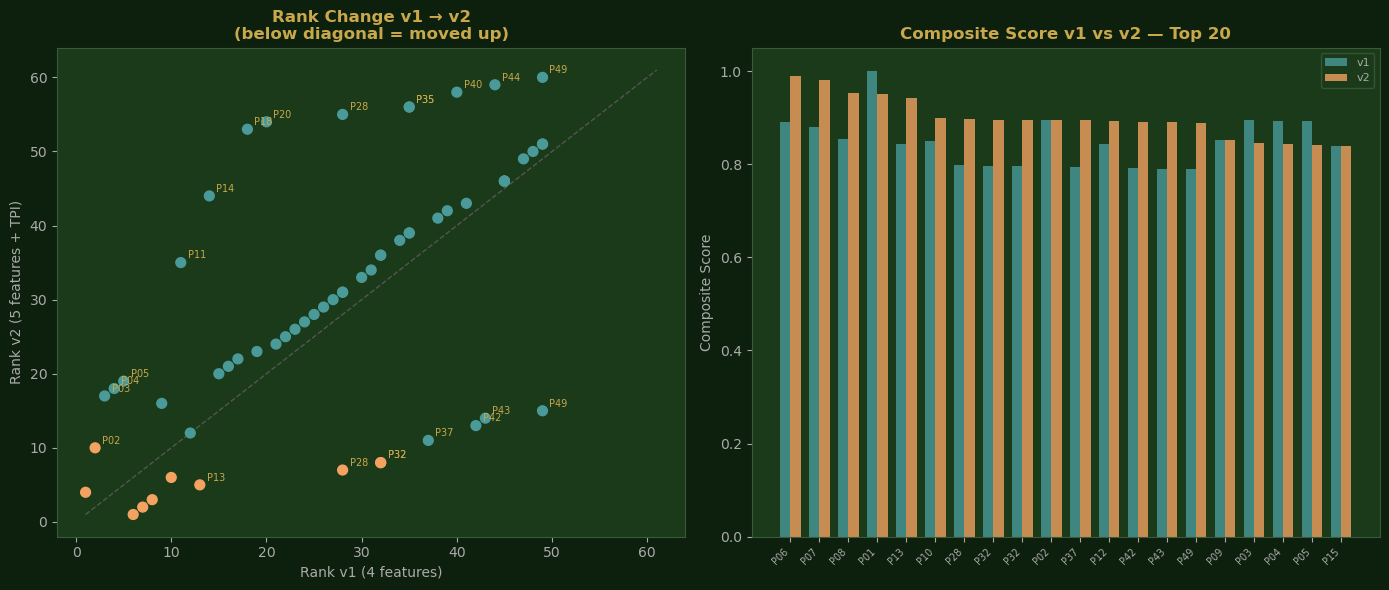

Saved: outputs/rank_change_v1_v2.png


In [14]:
# ── Cell 8: Rank change visualization ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0d1f0d')

ax = axes[0]
clrs = ['#f4a261' if r <= 10 else '#4a9a9a' for r in df_out['rank_v2']]
ax.scatter(df_out['rank_v1'], df_out['rank_v2'], c=clrs, s=50, zorder=3)
lim = len(df_out) + 1
ax.plot([1, lim], [1, lim], color='#555', lw=1, ls='--')
for _, row in df_out.iterrows():
    if abs(row['rank_delta']) >= 8:
        ax.annotate(f"P{int(row['rank_v1']):02d}",
                    (row['rank_v1'], row['rank_v2']),
                    textcoords='offset points', xytext=(5, 3),
                    fontsize=7, color='#c9a84c')
ax.set_xlabel('Rank v1 (4 features)', color='#aaaaaa')
ax.set_ylabel('Rank v2 (5 features + TPI)', color='#aaaaaa')
ax.set_title('Rank Change v1 → v2\n(below diagonal = moved up)', color='#c9a84c', fontweight='bold')
ax.set_facecolor('#1a3a1a'); ax.tick_params(colors='#aaaaaa')
for sp in ax.spines.values(): sp.set_edgecolor('#3a5a3a')

ax2 = axes[1]
top20 = df_out.head(20)
labels = [f"P{int(r['rank_v1']):02d}" for _, r in top20.iterrows()]
x = np.arange(len(top20))
w = 0.35
ax2.bar(x - w/2, top20['composite_score'], w, label='v1', color='#4a9a9a', alpha=0.8)
ax2.bar(x + w/2, top20['composite_v2'],    w, label='v2', color='#f4a261', alpha=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax2.set_ylabel('Composite Score', color='#aaaaaa')
ax2.set_title('Composite Score v1 vs v2 — Top 20', color='#c9a84c', fontweight='bold')
ax2.legend(fontsize=8, facecolor='#1a3a1a', labelcolor='#aaaaaa', edgecolor='#3a5a3a')
ax2.set_facecolor('#1a3a1a'); ax2.tick_params(colors='#aaaaaa')
for sp in ax2.spines.values(): sp.set_edgecolor('#3a5a3a')

fig.patch.set_facecolor('#0d1f0d')
plt.tight_layout()
plt.savefig(OUT_DIR / 'rank_change_v1_v2.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1f0d')
plt.show()
print('Saved: outputs/rank_change_v1_v2.png')

In [16]:
# ── Cell 9: Summary ────────────────────────────────────────────────────────

top1        = df_out.iloc[0]
movers_up   = df_out[df_out['rank_delta'] >= 5]
movers_down = df_out[df_out['rank_delta'] <= -5]

print(f"""
{'='*60}
  PaleoWave Model v2 — TPI Post-hoc Adjustment
{'='*60}
  v1 model: RF with {FEATURE_COLS_V1}
  v2 scoring: composite_score + tpi_adj (±0.10, within 15km TRc only)

  Train AUC v1: {auc1:.3f}
  Train AUC v2: n/a — TPI applied post-hoc, not retrained
  (honest LOO recall in notebook 07)

  Top target (v2 rank #1):
    Coords:    {top1['latitude']:.4f}N  {abs(top1['longitude']):.4f}W
    v1 score:  {top1['composite_score']:.3f}
    TPI adj:   {top1['tpi_adj']:+.2f}
    Composite: {top1['composite_v2']:.3f}
    TPI:       {top1['tpi_15m']:+.1f}m
    Dist TRc:  {int(top1['dist_to_triassic_m'])}m
    v1 rank:   #{int(top1['rank_v1'])}

  Big movers (≥5 places):
    Moved UP:   {len(movers_up)}
    Moved DOWN: {len(movers_down)}

  Saved:
  data/model/paleowave_v2_top50.csv
  data/model/paleowave_v2_top50.geojson
  outputs/feature_importance_v2.png
  outputs/rank_change_v1_v2.png
{'='*60}""")


  PaleoWave Model v2 — TPI Post-hoc Adjustment
  v1 model: RF with ['elevation_m', 'slope_deg', 'aspect_deg', 'tri']
  v2 scoring: composite_score + tpi_adj (±0.10, within 15km TRc only)

  Train AUC v1: 1.000
  Train AUC v2: n/a — TPI applied post-hoc, not retrained
  (honest LOO recall in notebook 07)

  Top target (v2 rank #1):
    Coords:    40.8228N  117.6969W
    v1 score:  0.890
    TPI adj:   +0.10
    Composite: 0.990
    TPI:       -27.2m
    Dist TRc:  1309m
    v1 rank:   #6

  Big movers (≥5 places):
    Moved UP:   11
    Moved DOWN: 18

  Saved:
  data/model/paleowave_v2_top50.csv
  data/model/paleowave_v2_top50.geojson
  outputs/feature_importance_v2.png
  outputs/rank_change_v1_v2.png
